## L96 Experiments

The purpose of this notebook is to first test how long I should expect some long L96 experiments to take with kernel embeddings NLE, and then potentially to actually run those experiments out long here (or on orion depending on how long we're talking about).

In [66]:
import numpy as np 
import sys
sys.path.insert(0, '..')
import DAPyr as dap
import matplotlib.pyplot as plt
from importlib import reload
from scipy.io import loadmat
from scipy.sparse.linalg import eigsh
from scipy.stats import norm, cauchy

reload(dap)

np.set_printoptions(suppress=True)


In [67]:
poep = {'mu': 0, 'sigma': 2.0} 
poep_gaus_lg = {'mu': 0, 'sigma': 1.8} 
poep_gaus_cauchy = {'mu': 0, 'sigma': 0.5} 
# original experiments were gamma = 0.2!
uoep_cauchy = {'x0': 0, 'gamma': 0.34}
poep_cauchy = {'x0': 0, 'gamma': 0.34} 

uoep_logistic = {'x0': 0, 'scale' : 1}
poep_logistic = {'x0': 0, 'scale' : 1} 

uoep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1, 'threshold': 0}
poep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1, 'threshold': 0}


In [36]:
e_name=''
print(f'starting experiment')
bw = 0.02
knn = 0.1
# original experiments!
#bw = 0.02
#knn = 0.1
klb=0.0
e_sd_kecd = dap.Expt('l96-sdg-kecd', {'expt_flag': 3,
                       'model_flag':1,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 1,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_sd,
                       'prescribed_obs_err_params': poep,
                       'save_keest_pab':1,
                       'Ne':80,
                       'T': 2500,
                       'T_train': 400,
                       'nle_type': 5,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': bw,
                       'klb':klb,
                       'debug_nle_noDA': False})

#_sd_gaussian = dap.Expt('l96-sdg-gauss', {'expt_flag': 1,
#                     'model_flag':1,
#                     'localize':1,
#                     'obf': 2,
#                     'seed': 58,
#                     'qc_flag': 0,
#                     'used_obs_err': 1,
#                     'prescribed_obs_err': 0,
#                     'used_obs_err_params': uoep_sd,
#                     'prescribed_obs_err_params': poep,
#                     'save_keest_pab':1,
#                     'Ne':80,
#                     'T': 2500,
#                     'T_train': 400,
#                     'nle_type': 5,
#                     'nle_every': 50, 
#                     'Neig': 50,
#                     'knn_frac': knn,
#                     'bw_dm': bw,
#                     'klb':klb,
#                     'debug_nle_noDA': False})
#_sd_true = dap.Expt('l96-sdg-true', {'expt_flag': 1,
#                     'model_flag':1,
#                     'localize':1,
#                     'obf': 2,
#                     'seed': 58,
#                     'qc_flag': 0,
#                     'used_obs_err': 1,
#                     'prescribed_obs_err': 1,
#                     'used_obs_err_params': uoep_sd,
#                     'prescribed_obs_err_params': poep_sd,
#                     'save_keest_pab':1,
#                     'Ne':80,
#                     'T': 2500,
#                     'T_train': 400,
#                     'nle_type': 5,
#                     'nle_every': 50, 
#                     'Neig': 50,
#                     'knn_frac': knn,
#                     'bw_dm': bw,
#                     'klb':klb,
#                     'debug_nle_noDA': False})


starting experiment


In [37]:
print('starting e_sd_kecd')
dap.runDA(e_sd_kecd)
print('starting e sd gaus')
#dap.runDA(e_sd_gaussian)
print('starting e sd true')
#dap.runDA(e_sd_true)
#dap.plot_pab(e_sd_kecd, ax=ax, plot_states=True)
#ax.plot(np.linspace(-15, 15, 100), norm.pdf(np.linspace(-15, 15, 100), loc=4.08, scale=0.75), linewidth=2, linestyle='dotted', c='k')

starting e_sd_kecd
DB: Starting cycle 0
DB: Starting cycle 100
DB: Starting cycle 200
DB: Starting cycle 300
DB: Starting cycle 400
DB: Starting cycle 500
DB: Starting cycle 600
starting e sd gaus
starting e sd true


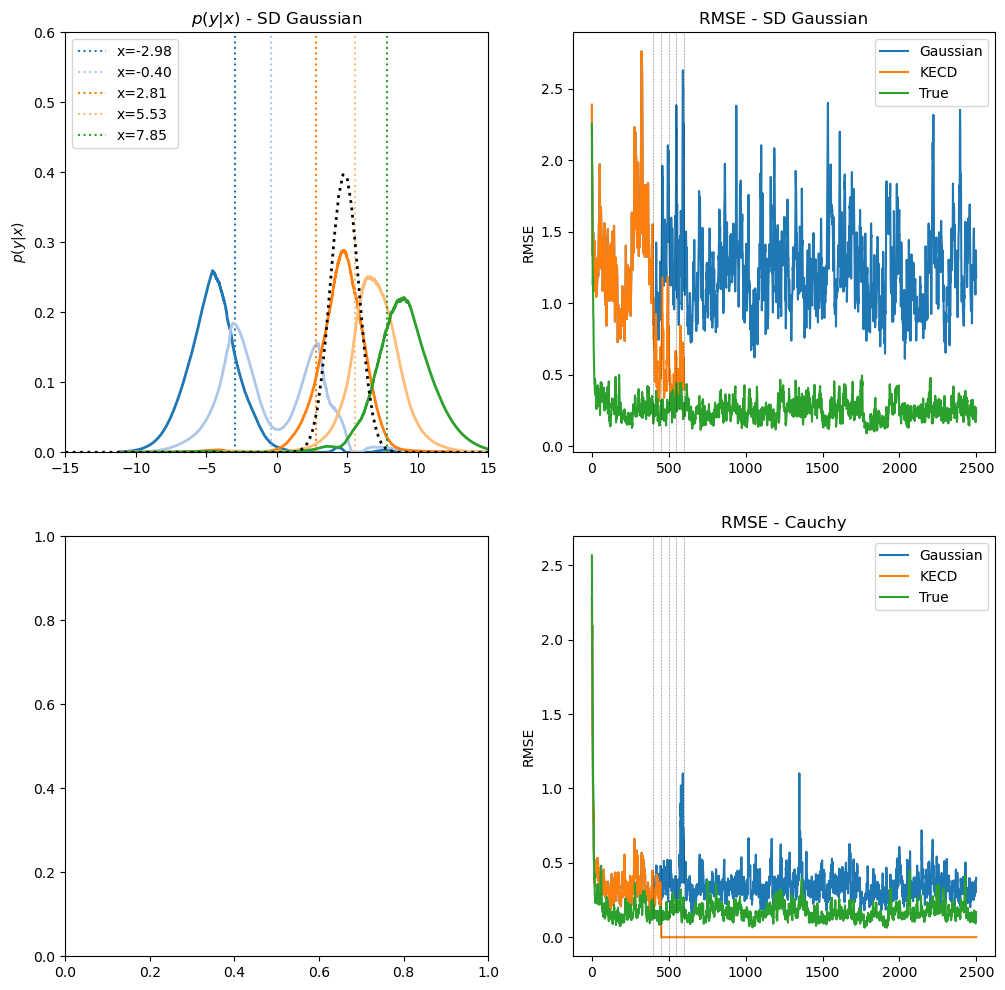

<Figure size 640x480 with 0 Axes>

In [70]:
fig, axs = plt.subplots(2,2, figsize=(12,12))
dap.plot_pab(e_sd_kecd, ax=axs[0,0], plot_states=True)
axs[0,0].set_title('$p(y|x)$ - SD Gaussian')
#dap.plot_pab(e_lg_kecd, ax=axs[1,0], plot_states=True)
xtrain_50 = np.quantile(e_sd_kecd.x_train, .50)
axs[0,0].plot(np.linspace(-15, 15, 100), norm.pdf(np.linspace(-15, 15, 100), loc=xtrain_50+2, scale=1), linewidth=2, linestyle='dotted', c='k')
#axs[1,0].set_title('$p(y|x)$ - Logistic')
#axs[1,0].plot(np.linspace(-15, 15, 100), logistic.pdf(np.linspace(-15, 15, 100), loc=2.15, scale=1.0), linewidth=2, linestyle='dotted', c='k')
axs[0,0].set_ylim(0,0.6)

axs[0,1].plot(e_sd_gaussian.rmse, label='Gaussian')
#axs[0,1].plot(e_sd_kecd.rmse, label='KECD')
axs[0,1].plot(rmse_mask, label='KECD')
axs[0,1].plot(e_sd_true.rmse, label='True')
axs[0,1].set_ylabel('RMSE')
axs[0,1].axvline(400, c='k', linestyle='dotted', linewidth=0.4)
axs[0,1].axvline(450, c='k', linestyle='dotted', linewidth=0.4)
axs[0,1].axvline(500, c='k', linestyle='dotted', linewidth=0.4)
axs[0,1].axvline(550, c='k', linestyle='dotted', linewidth=0.4)
axs[0,1].axvline(600, c='k', linestyle='dotted', linewidth=0.4)
axs[0,1].set_title('RMSE - SD Gaussian')
axs[0,1].legend()
axs[0,0].set_xlim(-15, 15)
axs[0,0].set_xlabel('')



axs[1,1].plot(e_ch_gaussian.rmse, label='Gaussian')
axs[1,1].plot(e_ch_kecd.rmse, label='KECD')
axs[1,1].plot(e_ch_true.rmse, label='True')
axs[1,1].set_ylabel('RMSE')
axs[1,1].set_title('RMSE - Cauchy')
axs[1,1].axvline(400, c='k', linestyle='dotted', linewidth=0.4)
axs[1,1].axvline(450, c='k', linestyle='dotted', linewidth=0.4)
axs[1,1].axvline(500, c='k', linestyle='dotted', linewidth=0.4)
axs[1,1].axvline(550, c='k', linestyle='dotted', linewidth=0.4)
axs[1,1].axvline(600, c='k', linestyle='dotted', linewidth=0.4)
axs[1,1].legend()
fig.savefig('l96_sdch_paper.png')


In [115]:
dap.saveExpt('./data/experiments/',e_sd_kecd)

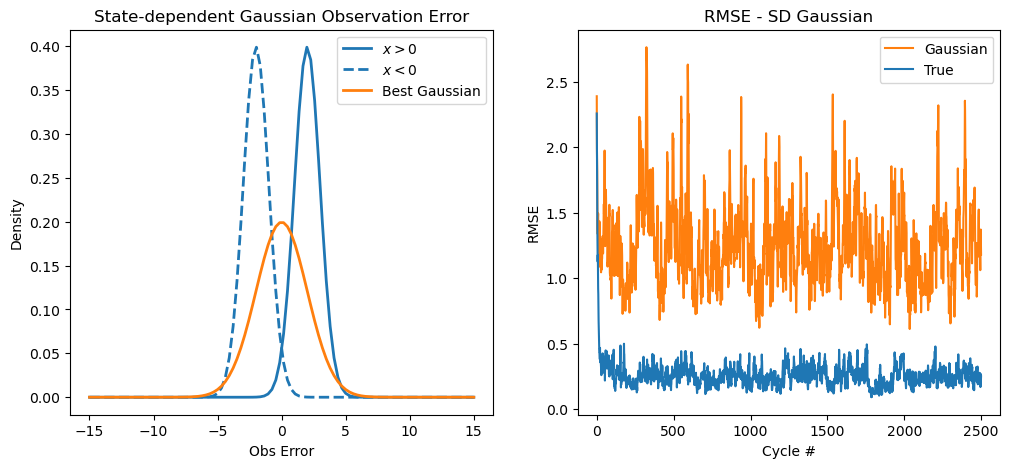

In [7]:
fig, axs = plt.subplots(1,2, figsize=(12,5), sharey='col', sharex='col')
axs[0].set_title('State-dependent Gaussian Observation Error')
axs[0].plot(np.linspace(-15, 15, 100), norm.pdf(np.linspace(-15, 15, 100), loc=2, scale=1), linewidth=2, c='C0', label='$x > 0$')
axs[0].plot(np.linspace(-15, 15, 100), norm.pdf(np.linspace(-15, 15, 100), loc=-2, scale=1), linewidth=2, linestyle='dashed', c='C0', label='$x < 0$')
axs[0].plot(np.linspace(-15, 15, 100), norm.pdf(np.linspace(-15, 15, 100), loc=0, scale=2), linewidth=2, c='C1', label='Best Gaussian')
axs[0].set_ylabel('Density')
axs[0].set_xlabel('Obs Error')
axs[0].legend()

axs[1].plot(e_sd_gaussian.rmse, label='Gaussian', c='C1')
axs[1].plot(e_sd_true.rmse, label='True', c='C0')
axs[1].set_ylabel('RMSE')
axs[1].set_title('RMSE - SD Gaussian')
axs[1].set_xlabel('Cycle #')
axs[1].legend()

plt.savefig('sdobserr.png')



In [68]:
e_ch_kecd = dap.Expt('e_ch_kecd', {'expt_flag': 3,
                       'model_flag':1,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 3,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_cauchy,
                       'prescribed_obs_err_params': poep_gaus_cauchy,
                       'save_keest_pab':1,
                       'Ne':80,
                       'T': 2500,
                       'T_train': 400,
                       'nle_type': 5,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': bw,
                       'klb':klb,
                       'debug_nle_noDA': False})

#######################t('e_ch_gauss', {'expt_flag': 1,
#######################model_flag':1,
#######################localize':1,
#######################obf': 2,
#######################seed': 58,
#######################qc_flag': 0,
#######################used_obs_err': 3,
#######################prescribed_obs_err': 0,
#######################used_obs_err_params': uoep_cauchy,
#######################prescribed_obs_err_params': poep_gaus_cauchy,
#######################save_keest_pab':1,
#######################Ne':80,
#######################T': 2500,
#######################T_train': 400,
#######################nle_type': 5,
#######################nle_every': 50, 
#######################Neig': 50,
#######################knn_frac': knn,
#######################bw_dm': bw,
#######################klb':klb,
#######################debug_nle_noDA': False})
#######################_ch_true', {'expt_flag': 1,
#######################model_flag':1,
#######################localize':1,
#######################obf': 2,
#######################seed': 58,
#######################qc_flag': 0,
#######################used_obs_err': 3,
#######################prescribed_obs_err': 3,
#######################used_obs_err_params': uoep_cauchy,
#######################prescribed_obs_err_params': poep_cauchy,
#######################save_keest_pab':1,
#######################Ne':80,
#######################T': 2500,
#######################T_train': 400,
#######################nle_type': 5,
#######################nle_every': 50, 
#######################Neig': 50,
#######################knn_frac': knn,
#######################bw_dm': bw,
#######################klb':klb,
#######################debug_nle_noDA': False})

In [69]:
dap.runDA(e_ch_kecd)
#dap.runDA(e_ch_gaussian)
#dap.runDA(e_ch_true)

DB: Starting cycle 0
DB: Starting cycle 100
DB: Starting cycle 200
DB: Starting cycle 300
DB: Starting cycle 400


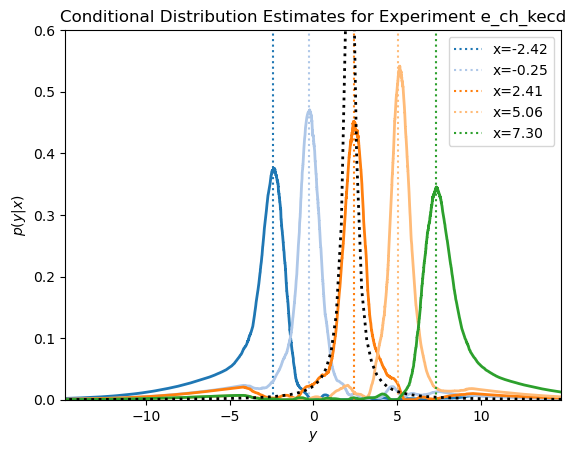

<Figure size 640x480 with 0 Axes>

In [44]:
fig, ax = plt.subplots()
dap.plot_pab(e_ch_kecd, plot_states=True, ax=ax)
ax.set_ylim(0,0.6)
ax.plot(np.linspace(-15, 15, 100), cauchy.pdf(np.linspace(-15, 15, 100), loc=2.18, scale=0.34), linewidth=2, linestyle='dotted', c='k')

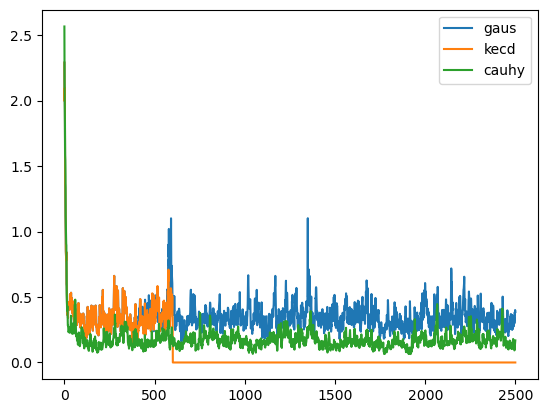

In [45]:
plt.plot(e_ch_gaussian.rmse, label='gaus')
plt.plot(e_ch_kecd.rmse, label='kecd')
plt.plot(e_ch_true.rmse, label='cauhy')
plt.legend()

In [31]:
rmse_mask = np.where(e_sd_kecd.rmse==0, np.nan, e_sd_kecd.rmse)